In [29]:
from pathlib import Path
import sys
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
sys.path.insert(0, str(root))

from src.data_download import download_data
import json 
import pandas as pd
import pickle
import os

data_dir = Path("../data")

In [30]:
# List the categories to download here
categories = ["All_Beauty"]
reload_data = False

if reload_data:
    for category in categories:
        download_data(category)


## Overview of the dataset

We performed the following EDA to inspect the datasets:
- **Dataset size inspection:** Counted the number of records in both datasets (reviews and metadata).
- **Field inspection:** Listed all available fields in the reviews and metadata datasets.
- **Sample record inspection:** Printed example records from both datasets to understand the data structure and relationships between fields.
- **Missing value analysis:** Calculated the percentage of missing values for each field to determine data completeness.
- **Rating distribution analysis:** Visualized the distribution of review ratings to understand overall sentiment patterns in the dataset.

In [31]:
for category in categories:
    review_file = f"../data/raw/{category}.jsonl"
    metadata_file = f"../data/raw/meta_{category}.jsonl"

    print(f"Data exploration for {category} dataset:")

    # Read reviews
    reviews = []
    with open(review_file, "r") as f:
        for line in f:
            reviews.append(json.loads(line))

    # Read metadata
    meta = []
    with open(metadata_file, "r") as f:
        for line in f:
            meta.append(json.loads(line))

    print("Reviews count:", len(reviews))
    print("Metadata count:", len(meta))

    print("Review fields:", list(reviews[0].keys()))
    print("Metadata fields:", list(meta[0].keys()))

    print("First review:", reviews[0])
    print("First metadata record:", meta[0])


Data exploration for All_Beauty dataset:
Reviews count: 701528
Metadata count: 112590
Review fields: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Metadata fields: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']
First review: {'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': Tr

In [43]:
reviews_df = pd.DataFrame(reviews)
meta_df = pd.DataFrame(meta)

In [44]:
print("Percentage of missing values in reviews:")
print(reviews_df.isna().mean() * 100)
print("Percentage of missing values in metadata:")
print(meta_df.isna().mean() * 100) 

Percentage of missing values in reviews:
rating               0.0
title                0.0
text                 0.0
images               0.0
asin                 0.0
parent_asin          0.0
user_id              0.0
timestamp            0.0
helpful_vote         0.0
verified_purchase    0.0
dtype: float64
Percentage of missing values in metadata:
main_category        0.000000
title                0.000000
average_rating       0.000000
rating_number        0.000000
features             0.000000
description          0.000000
price               84.275691
images               0.000000
videos               0.000000
store               10.063949
categories           0.000000
details              0.000000
parent_asin          0.000000
bought_together    100.000000
dtype: float64


Rating distribution:


<Axes: >

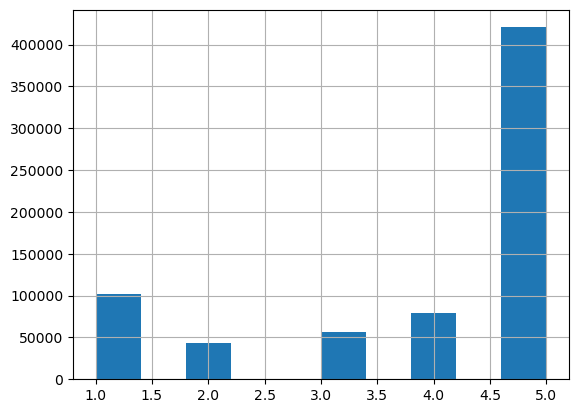

In [45]:
print("Rating distribution:")
reviews_df["rating"].hist()

## Selection and justification of fields for retrieval

We selected the following subset of fields for retrieval from the reviews and metadaset as these fields contain meaningful textual information describing the product and how the other users felt after using the product.

| Dataset   | Field | Reason for Inclusion |
|----------|-------|----------------------|
| Metadata | title | Contains product title which identifies the product type, brand and keywords related to the product that are often directly represented in the user's product query. |
| Reviews  | text  | Contains product reviews from other users of how relevant and useful the product is in natural language. |

## Description of text preprocessing decisions

We performed the following text preprocessing in the text_tokenizer function in the bm25.py script:
- **Lowercasing**  
   All text was converted to lowercase to ensure that all tokens are treated as the same word. This reduces unnecessary vocabulary duplication and improves matching between queries and documents.

- **Punctuation Removal**  
   Punctuation characters were removed using a regular expression. This ensures that all tokens are treated consistently and prevents punctuation from being included as part of tokens.

- **Whitespace Tokenization**  
   After normalization, text was split into tokens using whitespace.

- **Stopword Removal**  
   Common English stopwords (e.g., *the*, *and*, *is*, *to*) were removed to reduce noise in the tokenized corpus. These words appear frequently but provide little semantic value for distinguishing relevant documents.

In [32]:
from langchain_core.documents import Document
from src.bm25 import text_tokenizer, build_bm25, bm25_search

tokenized_corpus_file = os.path.join(data_dir, "processed", "tokenized_corpus.pkl")
reload_tokenized_corpus = True

documents = []
tokenized_corpus = []

metadata_lookup = {
    item["parent_asin"]: item
    for item in meta
}

if os.path.exists(tokenized_corpus_file) and not reload_tokenized_corpus:
    print("Loading tokenized corpus...")
    
    with open(tokenized_corpus_file, "rb") as f:
        tokenized_corpus = pickle.load(f)

else:
    print("Generating tokenized corpus...")

for review in reviews:

    product_metadata = metadata_lookup.get(review["parent_asin"], {})

    combined_text = " ".join([
        product_metadata.get("title", ""),              # used in old version
        # " ".join(product_metadata.get("description", [])),
        # " ".join(product_metadata.get("features", [])),
        # review.get("title", ""),
        review.get("text", "")
    ])

    tokens = text_tokenizer(combined_text)

    tokenized_corpus.append(tokens)


with open(tokenized_corpus_file, "wb") as f:
    pickle.dump(tokenized_corpus, f)


# Build documents (needed for BM25 search)
for tokens, review in zip(tokenized_corpus, reviews):

    processed_text = " ".join(tokens)

    product_metadata = metadata_lookup.get(review["parent_asin"], {})

    documents.append(
        Document(
            page_content=processed_text,
            metadata={
                "asin": review["parent_asin"],
                "product_review": review.get("text", ""),
                "product_title": product_metadata.get("title", ""),
                "product_rating": review.get("rating", "")
            }
        )
    )


Generating tokenized corpus...


In [33]:
bm25_index_path = "../data/processed/bm25_index.pkl"
rebuild_bm25 = True

if os.path.exists(bm25_index_path) and not rebuild_bm25:

    print("Loading existing BM25 index...")

    with open(bm25_index_path, "rb") as f:
        bm25 = pickle.load(f)

else:

    print("Building BM25 index...")

    bm25 = build_bm25(documents)

    with open(bm25_index_path, "wb") as f:
        pickle.dump(bm25, f)

Building BM25 index...


In [34]:
# This is how you pass a query to the BM25 search

query = "wireless bluetooth headphones"

results = bm25_search(bm25, documents, query, k=5)

for doc, score in results:
    print("Product Title:", doc.metadata.get("product_title"))
    print("Product Review:", doc.metadata.get("product_review")[:200])
    print("ASIN:", doc.metadata.get("asin"))
    print("Product Rating:", doc.metadata.get("product_rating"))
    print("Retrieval Score:", score)
    print()

Product Title: Wireless Earbuds, 455D Stereo Sound Wireless Headphones Wireless Sport Earbud with Breathing Mini in-Ear Sports Earphones Noise Cancelling Headsets, Bluetooth Earbuds
Product Review: Works fine...
ASIN: B014VTGC9I
Product Rating: 5.0
Retrieval Score: 35.066935752274375

Product Title: Yontune Sleep Headphones Headband Timing Wireless Cozy Band Washable for Running Workout Unique Gifts (Lengthened), Black grey
Product Review: Bluetooth didn’t turn on
ASIN: B0B533WQVC
Product Rating: 1.0
Retrieval Score: 31.791503280805657

Product Title: FENCHILIN Vanity Mirror with Lights Bluetooth Lighted Makeup Mirror Touch Screen Wireless Audio Speaker Dimmable Light Detachable 10X Magnification Rechargable Power (Rose Gold)
Product Review: Love the mirror and light's.  Has bluetooth. Can change mirror different positions.
ASIN: B0769VLLW6
Product Rating: 5.0
Retrieval Score: 21.152462808027963

Product Title: FENCHILIN Vanity Mirror with Lights Bluetooth Lighted Makeup Mirror Touch S

In [35]:
# This is how you pass a query to the semantic search

from src.semantic import semantic_search

query = "wireless bluetooth headphones"

results = semantic_search(documents, query, k=5, sample_size=10000, reload_index=True)

for doc, score in results:
    print("Product Title:", doc.metadata.get("product_title"))
    print("Product Review:", doc.metadata.get("product_review")[:200])
    print("ASIN:", doc.metadata.get("asin"))
    print("Product Rating:", doc.metadata.get("product_rating"))
    print("Retrieval Score:", score)
    print()

Product Title: Earbuds Ear Buds Sport Earbuds Running Earbuds in Ear Headphones Wired Earphones with Microphone Mic Stereo and Volume Control Waterproof Wired Earphone Android Mp3 Players Tablet Laptop 3.5mm Audio
Product Review: Other reviews are not for this product. Does not fit well in ear and doesn't come with any way to change fit/size. Can hardly wear when sitting on the couch so there's no way they'd work for running. 
ASIN: B07KQ4XNDV
Product Rating: 1.0
Retrieval Score: 1.0669926

Product Title: MMUSS Sleep Headphones Headband with Ultra Thin Stereo Speakers.Perfect for Sleeping,Sports,Air Travel,Meditation and Relaxation(Black2)
Product Review: I love these. Very comfortable and great sound quality.
ASIN: B07JQ136H9
Product Rating: 5.0
Retrieval Score: 1.0892053

Product Title: Nxconsu 12Pcs Headbands for Women Girls Teens Elastic Hair Bands Silky Solid Colors Pleated Crinkle Head Band Fashion Trendy Outfit Colorful Thin Comfortable Hair Accessories for Home Work Gym Casual
